# Efficient Frontier Construction in Python

*Quant Lab · The Analytical Investor · Year 1, Month 4*

**Read the article:** [Efficient Frontier Construction in Python](https://analytical-investor.blog/?p=1003)

We simulate 50,000 random portfolios of equities, bonds and real estate, and watch the efficient frontier appear as the upper-left edge of the cloud.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Set the planning assumptions, simulate random long-only portfolios, locate the minimum-variance and maximum-Sharpe portfolios, and plot the cloud.

Minimum-variance portfolio
{'Equities': np.float64(0.013), 'Bonds': np.float64(0.839), 'Real Estate': np.float64(0.148)} ret=5.36%, vol=5.65%
Maximum-Sharpe (tangency) portfolio
{'Equities': np.float64(0.218), 'Bonds': np.float64(0.649), 'Real Estate': np.float64(0.133)} ret=6.36%, vol=6.75%, Sharpe=0.50


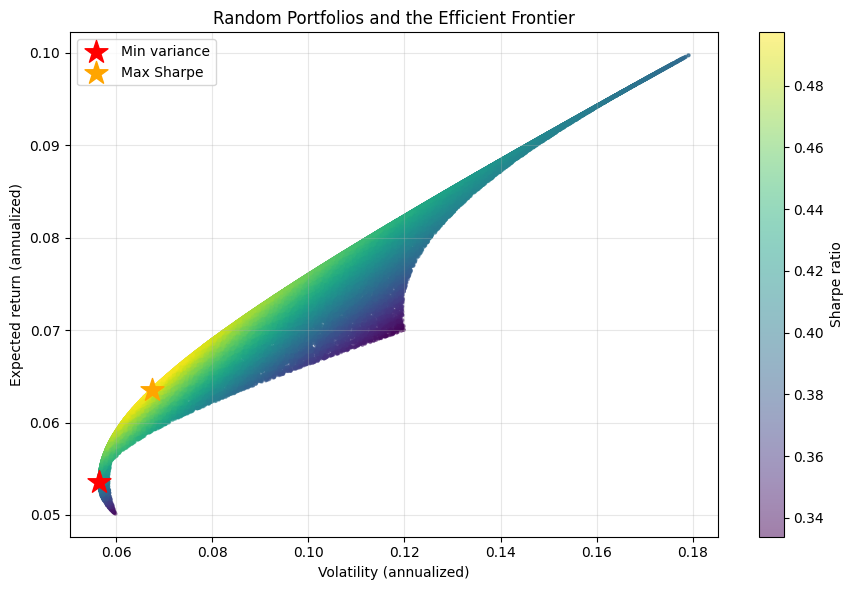

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Assumptions: long-run annual figures for three asset classes.
#    These are illustrative planning assumptions, not forecasts.
# ------------------------------------------------------------------
assets = ["Equities", "Bonds", "Real Estate"]
mu     = np.array([0.10, 0.05, 0.07])      # expected annual returns
vol    = np.array([0.18, 0.06, 0.12])      # annual volatilities

corr = np.array([[1.00, 0.10, 0.60],       # correlation matrix
                 [0.10, 1.00, 0.15],
                 [0.60, 0.15, 1.00]])

cov = np.outer(vol, vol) * corr            # covariance matrix
rf  = 0.03                                 # risk-free rate

# ------------------------------------------------------------------
# 2. Simulate random long-only portfolios
# ------------------------------------------------------------------
rng = np.random.default_rng(42)
n_portfolios = 50_000

w = rng.dirichlet(np.ones(len(assets)), n_portfolios)  # rows sum to 1
port_ret = w @ mu
port_vol = np.sqrt(np.einsum('ij,jk,ik->i', w, cov, w))
sharpe   = (port_ret - rf) / port_vol

# ------------------------------------------------------------------
# 3. Locate the two key portfolios
# ------------------------------------------------------------------
i_minvar = port_vol.argmin()
i_maxsr  = sharpe.argmax()

print("Minimum-variance portfolio")
print(dict(zip(assets, w[i_minvar].round(3))),
      f"ret={port_ret[i_minvar]:.2%}, vol={port_vol[i_minvar]:.2%}")

print("Maximum-Sharpe (tangency) portfolio")
print(dict(zip(assets, w[i_maxsr].round(3))),
      f"ret={port_ret[i_maxsr]:.2%}, vol={port_vol[i_maxsr]:.2%}, "
      f"Sharpe={sharpe[i_maxsr]:.2f}")

# ------------------------------------------------------------------
# 4. Plot the cloud and the frontier
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(port_vol, port_ret, c=sharpe, s=4,
                cmap="viridis", alpha=0.5)
ax.scatter(port_vol[i_minvar], port_ret[i_minvar],
           marker="*", s=300, c="red", label="Min variance")
ax.scatter(port_vol[i_maxsr], port_ret[i_maxsr],
           marker="*", s=300, c="orange", label="Max Sharpe")
ax.set_xlabel("Volatility (annualized)")
ax.set_ylabel("Expected return (annualized)")
ax.set_title("Random Portfolios and the Efficient Frontier")
fig.colorbar(sc, label="Sharpe ratio")
ax.legend()
plt.tight_layout()
plt.show()

### The exact frontier
The random cloud approximates the frontier. A constrained optimizer traces it exactly; the red line should hug the cloud's upper-left edge.

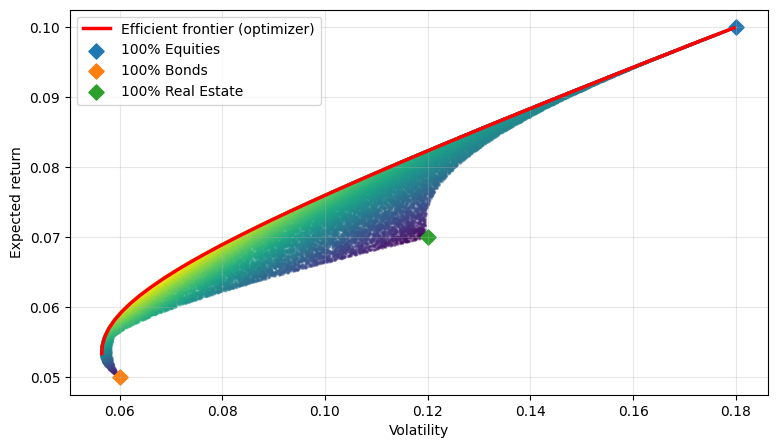

In [3]:
from analytical_investor import portfolio as P

targets, fvol, _ = P.efficient_frontier(mu, cov, n_points=40)
plt.scatter(port_vol, port_ret, c=sharpe, s=2, cmap="viridis", alpha=0.3)
plt.plot(fvol, targets, "r-", lw=2.5, label="Efficient frontier (optimizer)")
for i, lab in enumerate(assets):
    plt.scatter(vol[i], mu[i], marker="D", s=60, label=f"100% {lab}")
plt.xlabel("Volatility"); plt.ylabel("Expected return"); plt.legend(); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [4]:
w = P.max_sharpe(mu, cov, rf=rf)
print("Exact tangency weights:", dict(zip(assets, w.round(3))))
print(f"Sharpe {(P.portfolio_return(w, mu) - rf) / P.portfolio_volatility(w, cov):.3f}")

Exact tangency weights: {'Equities': np.float64(0.22), 'Bonds': np.float64(0.649), 'Real Estate': np.float64(0.131)}
Sharpe 0.497


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1003).